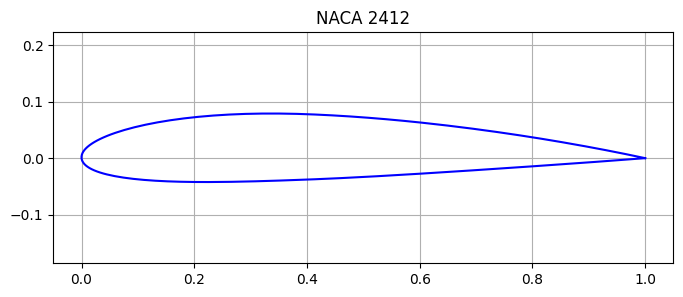

198 panels created
(198, 198)
[-0.0098941  -0.0220393   0.47679899  0.04529323  0.36247248  0.14189038
  0.28184312  0.18995852  0.24360516  0.2079715 ]
[-0.0098941  -0.0220393   0.47679899  0.04529323  0.36247248  0.14189038
  0.28184312  0.18995852  0.24360516  0.2079715   0.22526612  0.21272807
  0.21501647  0.21180079  0.20783819  0.20832609  0.20167876  0.2035897
  0.19571319  0.19812584  0.18961944  0.19216592  0.18328111  0.18581923
  0.17666538  0.17914485  0.16977246  0.17217986  0.16261413  0.16495003
  0.15520424  0.15747352  0.14755428  0.14976193  0.13967111  0.14182039
  0.13155578  0.13364735  0.12320281  0.12523444  0.11459989  0.11656629
  0.1057277   0.10762056  0.09655986  0.0983679   0.08706298  0.088772
  0.07719662  0.07878955  0.06691335  0.06837055  0.05615941  0.0574593
  0.04487376  0.04598431  0.03292178  0.03076841  0.01625308  0.01396841
 -0.00095171 -0.00333778 -0.01865543 -0.0211164  -0.03683152 -0.03934734
 -0.05547069 -0.05803033 -0.07458676 -0.07719107

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def naca4(code, n=100, closed_te=True):
    m = int(code[0]) / 100.0 # m means max camber which max vertical disrace between chmaber line and chord line/chord line
    p = int(code[1]) / 10.0 # p means position along chord from leading edge of max camber, if p=4, this will be at o.4c
    t = int(code[2:]) / 100.0 # t is max thicness between upper and lower surface measured perpendicular to the camber line, if t=12, then thickness is 0.12c

    beta = np.linspace(0, np.pi, n) # this creates n x coordinates from 0 to pi
    x = (1 - np.cos(beta)) / 2  # cosine spacing, beta is the angle between the horizontal and the panel's normal

    a4 = -0.1015 if not closed_te else -0.1036 # a tweak to correct the tip of the tail (trailing edge)
    yt = 5*t*(0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 + a4*x**4) # computes half the thickness exactly between upper and lower surfae at each x

    yc = np.zeros_like(x) # computes the y values of the camber line based on the x-values created
    dyc_dx = np.zeros_like(x) # calculates the slope of the camber
    if p > 0: # need to limit how gradient is calculated depending on where p is
        mask = x < p # formulas are different for when x is before position of max camber and after
        yc[mask] = (m/p**2) * (2*p*x[mask] - x[mask]**2) # computes the camber height for eahc x value
        dyc_dx[mask] = (2*m/p**2) * (p - x[mask]) # computes the camber slope
        yc[~mask] = (m/(1-p)**2) * ((1-2*p) + 2*p*x[~mask] - x[~mask]**2)
        dyc_dx[~mask] = (2*m/(1-p)**2) * (p - x[~mask])
        # these last 2 lines repeats the first two but for when x is bigger than p.

    theta = np.arctan(dyc_dx) # angle of camber based off the slope
    # following lines uses trig to calc upper and lower sruface x and y coordinates of foil

    xu = x - yt*np.sin(theta)
    yu = yc + yt*np.cos(theta)
    xl = x + yt*np.sin(theta)
    yl = yc - yt*np.cos(theta)

    # order: TE -> upper -> LE -> lower -> TE
    x_coords = np.concatenate([xu[::-1], xl[1:]]) # flips x-values order so it starts from the trailing edge
    y_coords = np.concatenate([yu[::-1], yl[1:]]) # smae as above but for y
    return x_coords, y_coords # concatenating joins the arrays together as a pair

x, y = naca4("2412", n=100) # sets graph cooridnates with 100 spacings

#following command plots graph
plt.figure(figsize=(8, 3))
plt.plot(x, y, 'b-')
plt.axis('equal')
plt.title("NACA 2412")
plt.grid(True)
plt.show()

# next we need to make panels:

def panelize(x_coords, y_coords): # this packs the whole function of maing segments
    n_panels = len(x_coords) - 1 # quantifies the number of panels

    x1 = x_coords[:-1]   # start point of each panel
    y1 = y_coords[:-1]
    x2 = x_coords[1:]    # end point of each panel
    y2 = y_coords[1:]

    # panel midpoints (control points, used to enforce boundary condition)
    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2

    # panel lengths
    S = np.sqrt((x2 - x1)**2 + (y2 - y1)**2) # pythagoras for distance between points/panel length

    # panel orientation angle (tangential direction)
    phi = np.arctan2(y2 - y1, x2 - x1) # panel angle from horizontal

    # outward normal angle = tangential angle rotated -90 degrees
    beta = phi + np.pi/2 # this is useful for ou rboundary condition

    return {
        'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
        'xm': xm, 'ym': ym, 'S': S, 'phi': phi, 'beta': beta,
        'n_panels': n_panels
    }

panels = panelize(x, y)
print(panels['n_panels'], "panels created") # should be 198 isnce one gone due one point gone due to beign the strat and end point, and naother gone due to having N-1 segments


# next we need to form this equation => (panels’ induced normal velocity)+(freestream’s normal velocity)=0
#first we'll find the induced normal velocity

n = panels['n_panels'] # the number n or 198 is pulled out from line 77
A = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            A[i, j] = 0.5  # panel's effect on itself - special case look back at notes, cant have ln(0)
        else:
            pass  # actual formula goes here next chunk

#next we need the fomrula to compute the sum of the effect of a panel on another panel's normal velocity
from scipy import integrate

def integral_normal(xi, yi, xj, yj, S_j, beta_j):  # xi and yi are the coordinates of the point on which the normal velocity is beeing measured as a result of the panel j
                                                   #
    def integrand(s): # s here is the length along the panel, s is going from 0 to S_j (full panel length)
        x_s = xj - np.sin(beta_j) * s # i think beta is the angle between the the panel normal and the freestream velocity
        y_s = yj + np.cos(beta_j) * s
        num = (xi - x_s) * np.cos(beta_j) + (yi - y_s) * np.sin(beta_j)
        den = (xi - x_s)**2 + (yi - y_s)**2
        return num / den
    result, _ = integrate.quad(integrand, 0, S_j)
    return result

# now we insert the midpoint coordinates of the panel into the function
n = panels['n_panels']
A = np.zeros((n, n))

for i in range(n): # loops through each panel's midpoint
    for j in range(n): # which panel is causing this normal vel.
        if i != j:
            A[i, j] = 0.5 / np.pi * integral_normal(
                panels['xm'][i], panels['ym'][i],
                panels['x1'][j], panels['y1'][j],
                panels['S'][j], panels['beta'][j]
            )
        else:
            A[i, j] = 0.5

print(A.shape)
A  # displays the array in Colab's output

# next we get the second part of the equation, htis should be easier
U_inf = 1.0    # freestream speed (can be anything for now - normalized)
alpha = 0.0    # angle of attack, in radians (0 = flow along the chord)

b = -U_inf * np.cos(panels['beta'] - alpha) # beta - alpha as angle needs to be adjusted if angle  of attack is not zero

# solve for lambda
lambda_ = np.linalg.solve(A, b)
print(lambda_[:10])  # peek at first 10 values

lambda_ = np.linalg.solve(A, b)
print(lambda_)

